In [36]:
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_Academy"
start_forecast_date = pd.to_datetime("2026-04-20").date()

prediction_files = sorted(pred_dir.glob(f"*{target_col}*profile_predictions.csv"))

print("Candidate files found:", len(prediction_files))


def detect_model_name(file_name):
    name = file_name.lower()

    if "random_forest" in name:
        return "random_forest"
    if "xgboost" in name:
        return "xgboost"
    if "catboost" in name:
        return "catboost"
    if "ridge" in name:
        return "ridge"
    if "linear_regression" in name:
        return "linear_regression"

    return "unknown"


def detect_resolution_from_horizons(n_horizons):
    if n_horizons == 96:
        return "15min", 0.25, 23, 45
    if n_horizons == 48:
        return "30min", 0.5, 23, 30
    if n_horizons == 24:
        return "60min", 1.0, 23, 0

    return "unknown", np.nan, None, None


def mape(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    mask = y_true != 0
    if mask.sum() == 0:
        return np.nan

    return np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100


def sort_horizon_columns(cols):
    """
    Sort horizon columns by number, not alphabetically.
    This prevents wrong order like 1, 10, 11, ..., 2, 20.
    """
    def horizon_number(col):
        # examples:
        # y_tplus_001_true
        # y_tplus_1_true
        parts = col.replace("_true", "").replace("_pred", "").split("_")
        nums = [p for p in parts if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)

Candidate files found: 138


In [37]:
rows = []
kept_files = []
skipped_files = []
bad_profile_rows = []

for file in prediction_files:
    model_name = detect_model_name(file.name)

    if model_name == "unknown":
        skipped_files.append((file.name, "unknown model name"))
        continue

    df = pd.read_csv(file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    if len(true_cols) == 0:
        skipped_files.append((file.name, "no true columns"))
        continue

    missing_pred_cols = [c for c in pred_cols if c not in df.columns]
    if missing_pred_cols:
        skipped_files.append((file.name, "missing pred columns"))
        continue

    n_horizons = len(true_cols)
    resolution, dt_hours, expected_issue_hour, expected_issue_minute = detect_resolution_from_horizons(n_horizons)

    if resolution == "unknown":
        skipped_files.append((file.name, f"unknown horizon count: {n_horizons}"))
        continue

    # Keep only correct issue time for that resolution
    issue_time_ok = (
        (df["issue_time"].dt.hour == expected_issue_hour) &
        (df["issue_time"].dt.minute == expected_issue_minute)
    )

    df = df[issue_time_ok].copy()

    if df.empty:
        skipped_files.append((file.name, f"wrong issue time for {resolution}"))
        continue

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    # Keep only forecast dates from 2026-04-20 onward
    df = df[df["forecast_date"] >= start_forecast_date].copy()

    if df.empty:
        skipped_files.append((file.name, "no forecast dates after start date"))
        continue

    # ------------------------------------------------------
    # Row-level quality filtering
    # ------------------------------------------------------
    good_rows = []

    for idx, r in df.iterrows():
        y_true_row = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred_row = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        valid = ~(np.isnan(y_true_row) | np.isnan(y_pred_row))

        # Require full horizon to be valid
        if valid.sum() != n_horizons:
            bad_profile_rows.append((file.name, r["forecast_date"], "incomplete horizon"))
            continue

        # Optional sanity check:
        # For this Tech Room load, a completely flat daily actual profile is suspicious.
        # This removes bad 60min runs that do not capture the daily operating pattern.
        actual_range = np.nanmax(y_true_row) - np.nanmin(y_true_row)
        actual_mean = np.nanmean(y_true_row)

        if actual_mean != 0:
            actual_range_ratio = actual_range / abs(actual_mean)
        else:
            actual_range_ratio = np.nan

        # If the day is almost flat, skip that row.
        # You can lower/raise 0.05 depending on your data.
        if actual_range_ratio < 0.05:
            bad_profile_rows.append((file.name, r["forecast_date"], "suspicious flat actual profile"))
            continue

        good_rows.append(idx)

    df_good = df.loc[good_rows].copy()

    if df_good.empty:
        skipped_files.append((file.name, "all rows failed quality filters"))
        continue

    y_true = df_good[true_cols].to_numpy(dtype=float).ravel()
    y_pred = df_good[pred_cols].to_numpy(dtype=float).ravel()

    mask = ~(np.isnan(y_true) | np.isnan(y_pred))
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    if len(y_true) == 0:
        skipped_files.append((file.name, "no valid values after filtering"))
        continue

    errors = y_true - y_pred

    kept_files.append(file.name)

    rows.append({
        "file_name": file.name,
        "model_name": model_name,
        "target_col": target_col,
        "resolution": resolution,
        "dt_hours": dt_hours,

        "first_forecast_date": df_good["forecast_date"].min(),
        "last_forecast_date": df_good["forecast_date"].max(),
        "n_forecast_days": df_good["forecast_date"].nunique(),
        "n_issue_times": len(df_good),

        "n_horizon_steps": n_horizons,
        "n_values": len(y_true),

        "MAE": mean_absolute_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAPE_%": mape(y_true, y_pred),
        "R2": r2_score(y_true, y_pred),

        "bias_actual_minus_pred": np.mean(errors),
        "error_std": np.std(errors),
    })


error_summary = pd.DataFrame(rows)

if not error_summary.empty:
    error_summary = error_summary.sort_values(
        ["resolution", "MAE"]
    ).reset_index(drop=True)

print("Files kept:", len(kept_files))
print("Files skipped:", len(skipped_files))
print("Bad profile rows:", len(bad_profile_rows))

display(error_summary)

Files kept: 48
Files skipped: 90
Bad profile rows: 0


,file_name,model_name,target_col,resolution,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-29,8,8,96,768,1.231587,1.763725,19.936692,0.779974,0.007880,1.763707
1,run_20260512_170951_44ea2b21_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-29,8,8,96,768,1.356431,1.947154,22.595143,0.731828,-0.174215,1.939345
2,run_20260521_130601_adf0c720_random_forest_BU_...,random_forest,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,1.636482,2.203536,28.031136,0.651989,-0.942602,1.991751
3,run_20260521_130558_e5a183f9_ridge_BU_TotActPw...,ridge,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,1.731762,2.349595,28.083061,0.604325,-0.148966,2.344868
4,run_20260521_130359_449f630a_random_forest_BU_...,random_forest,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,1.764812,2.540791,31.550272,0.537309,-0.740174,2.430589
5,run_20260521_130714_08110586_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,1.904803,2.460511,33.742836,0.566086,-1.189946,2.153634
6,run_20260521_130357_63eba77e_ridge_BU_TotActPw...,ridge,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,1.982328,2.895354,28.869469,0.399163,0.630758,2.825813
7,run_20260521_130506_6be56b9d_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,2.629510,3.661670,48.152087,0.039026,-1.780682,3.199531
8,run_20260526_154855_5f504912_random_forest_BU_...,random_forest,BU_TotActPwr_Academy,30min,0.50,2026-04-20,2026-04-30,11,11,48,528,1.572814,2.033778,28.281425,0.695043,-0.896188,1.825678
9,run_20260521_144254_7570873a_random_forest_BU_...,random_forest,BU_TotActPwr_Academy,30min,0.50,2026-04-20,2026-04-30,11,11,48,528,1.577674,2.037635,28.371370,0.693885,-0.898912,1.828638


In [38]:
skipped_files_df = pd.DataFrame(
    skipped_files,
    columns=["file_name", "reason"]
)

display(skipped_files_df)

,file_name,reason
0,run_20260410_125149_ea804389_ridge_BU_TotActPw...,no forecast dates after start date
1,run_20260410_125150_4cef49a4_random_forest_BU_...,no forecast dates after start date
2,run_20260410_125415_844d0b5a_xgboost_BU_TotAct...,no forecast dates after start date
3,run_20260410_143034_2fc58652_hist_gbr_BU_TotAc...,unknown model name
4,run_20260410_143121_3cf17790_xgboost_BU_TotAct...,no forecast dates after start date
...,...,...
85,run_20260521_153923_94547d33_random_forest_BU_...,wrong issue time for 30min
86,run_20260521_154001_d4e432e5_xgboost_BU_TotAct...,wrong issue time for 30min
87,run_20260608_130805_5a0afbf7_ridge_BU_TotActPw...,unknown horizon count: 240
88,run_20260608_130807_69b914a1_random_forest_BU_...,unknown horizon count: 240


In [39]:
bad_profile_rows_df = pd.DataFrame(
    bad_profile_rows,
    columns=["file_name", "forecast_date", "reason"]
)

display(bad_profile_rows_df)

,file_name,forecast_date,reason


In [40]:
best_60min = (
    error_summary[error_summary["resolution"] == "60min"]
    .sort_values("MAE")
    .iloc[0]
)

display(best_60min)

file_name                 run_20260521_093016_89fcbb0f_random_forest_BU_...
model_name                                                    random_forest
target_col                                             BU_TotActPwr_Academy
resolution                                                            60min
dt_hours                                                                1.0
first_forecast_date                                              2026-04-20
last_forecast_date                                               2026-04-30
n_forecast_days                                                          11
n_issue_times                                                            11
n_horizon_steps                                                          24
n_values                                                                264
MAE                                                                 1.30978
RMSE                                                               1.949535
MAPE_%      

In [41]:
best_per_model = (
    error_summary
    .sort_values("MAE")
    .groupby("model_name", as_index=False)
    .first()
)

display(best_per_model)

,model_name,file_name,target_col,resolution,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,BU_TotActPwr_Academy,60min,1.00,2026-04-20,2026-04-30,11,11,24,264,1.309780,1.949535,22.845292,0.708234,-0.267631,1.931078
1,ridge,run_20260521_130558_e5a183f9_ridge_BU_TotActPw...,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-30,11,11,96,1056,1.731762,2.349595,28.083061,0.604325,-0.148966,2.344868
2,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,BU_TotActPwr_Academy,15min,0.25,2026-04-20,2026-04-29,8,8,96,768,1.231587,1.763725,19.936692,0.779974,0.007880,1.763707


In [42]:
def calculate_energy_error_for_best_model(best_row, pred_dir):
    best_file = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    df = pd.read_csv(best_file)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"])

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    rows = []

    for _, r in df.iterrows():
        issue_time = r["issue_time"]

        y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
        y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

        # Constant baseline = first actual value in forecast horizon
        constant_load = y_true[0]
        y_constant = np.full_like(y_true, constant_load)

        mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

        y_true = y_true[mask]
        y_pred = y_pred[mask]
        y_constant = y_constant[mask]

        ml_residual = y_true - y_pred
        constant_residual = y_true - y_constant

        actual_energy_kWh = np.sum(y_true * dt_hours)
        ml_predicted_energy_kWh = np.sum(y_pred * dt_hours)
        constant_energy_kWh = np.sum(y_constant * dt_hours)

        ml_abs_energy_error_kWh = np.sum(np.abs(ml_residual) * dt_hours)
        constant_abs_energy_error_kWh = np.sum(np.abs(constant_residual) * dt_hours)

        rows.append({
            "issue_time": issue_time,
            "forecast_date": (issue_time + pd.Timedelta(days=1)).date(),
            "resolution": best_row["resolution"],
            "model_name": best_row["model_name"],
            "file_name": best_row["file_name"],

            "actual_energy_kWh": actual_energy_kWh,
            "ml_predicted_energy_kWh": ml_predicted_energy_kWh,
            "constant_energy_kWh": constant_energy_kWh,

            "ml_signed_energy_error_kWh": actual_energy_kWh - ml_predicted_energy_kWh,
            "constant_signed_energy_error_kWh": actual_energy_kWh - constant_energy_kWh,

            "ml_absolute_energy_error_kWh": ml_abs_energy_error_kWh,
            "constant_absolute_energy_error_kWh": constant_abs_energy_error_kWh,

            "ml_absolute_energy_error_%": (
                ml_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),
            "constant_absolute_energy_error_%": (
                constant_abs_energy_error_kWh / actual_energy_kWh * 100
                if actual_energy_kWh != 0 else np.nan
            ),

            "ml_improvement_vs_constant_kWh": (
                constant_abs_energy_error_kWh - ml_abs_energy_error_kWh
            ),
            "ml_improvement_vs_constant_%": (
                (constant_abs_energy_error_kWh - ml_abs_energy_error_kWh)
                / constant_abs_energy_error_kWh * 100
                if constant_abs_energy_error_kWh != 0 else np.nan
            ),

            "constant_load_kW": constant_load,
            "ml_mean_residual_kW": np.mean(ml_residual),
            "constant_mean_residual_kW": np.mean(constant_residual),
            "n_horizon_steps": len(y_true),
        })

    return pd.DataFrame(rows)

In [43]:
best_each_resolution = (
    error_summary
    .dropna(subset=["MAE"])
    .sort_values(["resolution", "MAE"])
    .groupby("resolution", as_index=False)
    .first()
)

display(best_each_resolution)

,resolution,file_name,model_name,target_col,dt_hours,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,n_values,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std
0,15min,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,xgboost,BU_TotActPwr_Academy,0.25,2026-04-20,2026-04-29,8,8,96,768,1.231587,1.763725,19.936692,0.779974,0.007880,1.763707
1,30min,run_20260526_154855_5f504912_random_forest_BU_...,random_forest,BU_TotActPwr_Academy,0.50,2026-04-20,2026-04-30,11,11,48,528,1.572814,2.033778,28.281425,0.695043,-0.896188,1.825678
2,60min,run_20260521_093016_89fcbb0f_random_forest_BU_...,random_forest,BU_TotActPwr_Academy,1.00,2026-04-20,2026-04-30,11,11,24,264,1.309780,1.949535,22.845292,0.708234,-0.267631,1.931078


In [44]:
energy_tables = []

for _, best_row in best_each_resolution.iterrows():
    energy_df = calculate_energy_error_for_best_model(best_row, pred_dir)
    energy_tables.append(energy_df)

energy_comparison_all_resolutions = pd.concat(energy_tables, ignore_index=True)

display(energy_comparison_all_resolutions)

,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
0,2026-04-19 23:45:00,2026-04-20,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,170.989663,159.148689,86.59992,11.840973,84.389742,27.896681,88.604867,16.314835,51.818845,60.708186,68.515634,3.60833,0.493374,3.516239,96
1,2026-04-22 23:45:00,2026-04-23,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,175.648115,164.065041,87.21600,11.583074,88.432115,29.166554,92.223790,16.605105,52.504856,63.057236,68.374153,3.63400,0.482628,3.684671,96
2,2026-04-23 23:45:00,2026-04-24,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,169.146847,161.492011,88.84800,7.654836,80.298848,21.926541,84.919162,12.963021,50.204402,62.992622,74.179513,3.70200,0.318952,3.345785,96
3,2026-04-24 23:45:00,2026-04-25,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,107.041170,141.467678,95.08008,-34.426508,11.961090,45.076272,21.525495,42.111154,20.109548,-23.550777,-109.408758,3.96167,-1.434438,0.498379,96
4,2026-04-25 23:45:00,2026-04-26,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,101.565835,120.914488,90.19992,-19.348653,11.365915,32.134562,17.781010,31.639145,17.506881,-14.353552,-80.724054,3.75833,-0.806194,0.473580,96
5,2026-04-26 23:45:00,2026-04-27,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,184.645417,159.383724,84.19200,25.261694,100.453417,32.259559,101.668753,17.471086,55.061617,69.409193,68.269937,3.50800,1.052571,4.185559,96
6,2026-04-27 23:45:00,2026-04-28,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,175.190500,184.958521,89.23200,-9.768021,85.958500,23.737287,90.079170,13.549414,51.417839,66.341883,73.648418,3.71800,-0.407001,3.581604,96
7,2026-04-28 23:45:00,2026-04-29,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,184.298830,175.583226,90.60792,8.715604,93.690910,24.267187,97.460375,13.167304,52.881711,73.193188,75.100458,3.77533,0.363150,3.903788,96
8,2026-04-11 23:30:00,2026-04-12,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,214.890835,280.420354,88.90392,-65.529519,125.986915,89.555151,128.507375,41.674719,59.801236,38.952224,30.311275,3.70433,-2.730397,5.249455,48
9,2026-04-12 23:30:00,2026-04-13,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,280.942655,216.792649,82.61592,64.150006,198.326735,77.074433,199.137705,27.434222,70.881976,122.063272,61.295912,3.44233,2.672917,8.263614,48


In [45]:
energy_summary_all_resolutions = (
    energy_comparison_all_resolutions
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_forecast_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(energy_summary_all_resolutions)

,resolution,model_name,file_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
0,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,8,158.565797,158.376672,88.996980,0.189125,69.568817,29.558080,74.282828,20.477633,43.938212,44.724747,29.744413,0.007880,2.898701
2,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,19,172.695941,177.981888,90.462644,-5.285947,82.233297,37.594903,85.787569,24.246163,45.981907,48.192666,17.050956,-0.220248,3.426387
1,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,19,172.731126,192.779421,92.420615,-20.048296,80.310511,44.606207,85.668922,27.731105,45.880491,41.062715,11.544116,-0.835346,3.346271


In [46]:
best_resolution_ml_comparison = energy_summary_all_resolutions[
    [
        "resolution",
        "model_name",
        "n_forecast_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_ml_signed_energy_error_kWh",
        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",
        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(best_resolution_ml_comparison)

,resolution,model_name,n_forecast_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_ml_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_ml_residual_kW,file_name
0,15min,xgboost,8,158.565797,158.376672,0.189125,29.558080,20.477633,0.007880,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
2,60min,random_forest,19,172.695941,177.981888,-5.285947,37.594903,24.246163,-0.220248,run_20260521_093016_89fcbb0f_random_forest_BU_...
1,30min,random_forest,19,172.731126,192.779421,-20.048296,44.606207,27.731105,-0.835346,run_20260526_154855_5f504912_random_forest_BU_...


In [47]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-20,2026-04-29,8
1,30min,2026-04-12,2026-04-30,19
2,60min,2026-04-12,2026-04-30,19


In [48]:
date_resolution_count = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .nunique()
    .reset_index(name="n_resolutions")
)

display(date_resolution_count.sort_values("forecast_date"))

,forecast_date,n_resolutions
0,2026-04-12,2
1,2026-04-13,2
2,2026-04-14,2
3,2026-04-15,2
4,2026-04-16,2
5,2026-04-17,2
6,2026-04-18,2
7,2026-04-19,2
8,2026-04-20,3
9,2026-04-21,2


In [49]:
required_resolutions = {"15min", "30min"}

available_by_date = (
    energy_comparison_all_resolutions
    .groupby("forecast_date")["resolution"]
    .apply(set)
)

common_dates = available_by_date[
    available_by_date.apply(lambda x: required_resolutions.issubset(x))
].index

energy_common_dates = energy_comparison_all_resolutions[
    energy_comparison_all_resolutions["forecast_date"].isin(common_dates)
].copy()

print("Common dates:", len(common_dates))
display(energy_common_dates.sort_values(["forecast_date", "resolution"]))

Common dates: 8


,issue_time,forecast_date,resolution,model_name,file_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,constant_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,constant_load_kW,ml_mean_residual_kW,constant_mean_residual_kW,n_horizon_steps
0,2026-04-19 23:45:00,2026-04-20,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,170.989663,159.148689,86.59992,11.840973,84.389742,27.896681,88.604867,16.314835,51.818845,60.708186,68.515634,3.60833,0.493374,3.516239,96
16,2026-04-19 23:30:00,2026-04-20,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,170.892415,182.790131,90.04008,-11.897716,80.852335,31.352578,86.918885,18.346384,50.861757,55.566307,63.928923,3.75167,-0.495738,3.368847,48
35,2026-04-19 23:00:00,2026-04-20,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,170.892890,157.669686,87.85800,13.223204,83.034890,25.158559,87.221390,14.721829,51.038630,62.062831,71.155517,3.66075,0.550967,3.459787,24
1,2026-04-22 23:45:00,2026-04-23,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,175.648115,164.065041,87.21600,11.583074,88.432115,29.166554,92.223790,16.605105,52.504856,63.057236,68.374153,3.63400,0.482628,3.684671,96
19,2026-04-22 23:30:00,2026-04-23,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,175.436360,173.140404,88.02408,2.295956,87.412280,29.437293,91.237650,16.779471,52.006123,61.800357,67.735586,3.66767,0.095665,3.642178,48
38,2026-04-22 23:00:00,2026-04-23,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,175.342410,164.050153,89.13792,11.292257,86.204490,23.811469,90.373110,13.579983,51.540931,66.561641,73.652042,3.71408,0.470511,3.591854,24
2,2026-04-23 23:45:00,2026-04-24,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,169.146847,161.492011,88.84800,7.654836,80.298848,21.926541,84.919162,12.963021,50.204402,62.992622,74.179513,3.70200,0.318952,3.345785,96
20,2026-04-23 23:30:00,2026-04-24,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,169.146845,184.288789,90.51192,-15.141944,78.634925,27.020136,84.096375,15.974366,49.717968,57.076239,67.870035,3.77133,-0.630914,3.276455,48
39,2026-04-23 23:00:00,2026-04-24,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,169.146820,169.173809,87.97992,-0.026989,81.166900,17.799463,84.155880,10.523085,49.753155,66.356417,78.849412,3.66583,-0.001125,3.381954,24
3,2026-04-24 23:45:00,2026-04-25,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,107.041170,141.467678,95.08008,-34.426508,11.961090,45.076272,21.525495,42.111154,20.109548,-23.550777,-109.408758,3.96167,-1.434438,0.498379,96


In [50]:
fair_resolution_comparison = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values("mean_ml_absolute_energy_error_kWh")
)

display(fair_resolution_comparison)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
0,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,8,158.565797,158.376672,88.99698,0.189125,69.568817,29.558080,20.477633,74.282828,43.938212,44.724747,29.744413,0.007880,2.898701
2,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,8,158.515481,164.015870,88.65150,-5.500389,69.863981,34.576039,25.591586,73.225176,43.307650,38.649138,-2.266626,-0.229183,2.910999
1,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,8,158.527170,178.946263,90.35703,-20.419093,68.170140,38.487983,27.410292,72.994736,43.148351,34.506753,-3.342269,-0.850796,2.840422


In [51]:
date_check = (
    energy_comparison_all_resolutions
    .groupby("resolution")["forecast_date"]
    .agg(
        first_date="min",
        last_date="max",
        n_days="nunique"
    )
    .reset_index()
)

display(date_check)

,resolution,first_date,last_date,n_days
0,15min,2026-04-20,2026-04-29,8
1,30min,2026-04-12,2026-04-30,19
2,60min,2026-04-12,2026-04-30,19


In [52]:
best_resolution_by_energy = fair_resolution_comparison.iloc[0]

display(best_resolution_by_energy)

resolution                                                                                 15min
model_name                                                                               xgboost
file_name                                      run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
n_common_days                                                                                  8
mean_actual_energy_kWh                                                                158.565797
mean_ml_predicted_energy_kWh                                                          158.376672
mean_constant_energy_kWh                                                                88.99698
mean_ml_signed_energy_error_kWh                                                         0.189125
mean_constant_signed_energy_error_kWh                                                  69.568817
mean_ml_absolute_energy_error_kWh                                                       29.55808
mean_ml_absolute_energy_error_

In [53]:
final_resolution_comparison = fair_resolution_comparison[
    [
        "resolution",
        "model_name",
        "n_common_days",

        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",

        "mean_ml_signed_energy_error_kWh",
        "mean_constant_signed_energy_error_kWh",

        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",

        "mean_constant_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_percent",

        "mean_ml_improvement_vs_constant_kWh",
        "mean_ml_improvement_vs_constant_percent",

        "mean_ml_residual_kW",
        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(final_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,file_name
0,15min,xgboost,8,158.565797,158.376672,88.99698,0.189125,69.568817,29.558080,20.477633,74.282828,43.938212,44.724747,29.744413,0.007880,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
2,60min,random_forest,8,158.515481,164.015870,88.65150,-5.500389,69.863981,34.576039,25.591586,73.225176,43.307650,38.649138,-2.266626,-0.229183,run_20260521_093016_89fcbb0f_random_forest_BU_...
1,30min,random_forest,8,158.527170,178.946263,90.35703,-20.419093,68.170140,38.487983,27.410292,72.994736,43.148351,34.506753,-3.342269,-0.850796,run_20260526_154855_5f504912_random_forest_BU_...


In [54]:
check_common = (
    energy_common_dates
    .groupby("forecast_date")["resolution"]
    .apply(lambda x: sorted(x.unique()))
    .reset_index()
)

display(check_common)

,forecast_date,resolution
0,2026-04-20,"[15min, 30min, 60min]"
1,2026-04-23,"[15min, 30min, 60min]"
2,2026-04-24,"[15min, 30min, 60min]"
3,2026-04-25,"[15min, 30min, 60min]"
4,2026-04-26,"[15min, 30min, 60min]"
5,2026-04-27,"[15min, 30min, 60min]"
6,2026-04-28,"[15min, 30min, 60min]"
7,2026-04-29,"[15min, 30min, 60min]"


In [55]:
# Day-wise comparison for only common forecast dates
daywise_resolution_comparison = energy_common_dates[
    [
        "forecast_date",
        "resolution",
        "model_name",

        "actual_energy_kWh",
        "ml_predicted_energy_kWh",
        "constant_energy_kWh",

        "ml_signed_energy_error_kWh",
        "constant_signed_energy_error_kWh",

        "ml_absolute_energy_error_kWh",
        "ml_absolute_energy_error_%",
        "constant_absolute_energy_error_kWh",
        "constant_absolute_energy_error_%",

        "ml_improvement_vs_constant_kWh",
        "ml_improvement_vs_constant_%",

        "ml_mean_residual_kW",
        "constant_mean_residual_kW",
        "file_name",
    ]
].sort_values(["forecast_date", "resolution"]).reset_index(drop=True)

display(daywise_resolution_comparison)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-20,15min,xgboost,170.989663,159.148689,86.59992,11.840973,84.389742,27.896681,16.314835,88.604867,51.818845,60.708186,68.515634,0.493374,3.516239,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
1,2026-04-20,30min,random_forest,170.892415,182.790131,90.04008,-11.897716,80.852335,31.352578,18.346384,86.918885,50.861757,55.566307,63.928923,-0.495738,3.368847,run_20260526_154855_5f504912_random_forest_BU_...
2,2026-04-20,60min,random_forest,170.892890,157.669686,87.85800,13.223204,83.034890,25.158559,14.721829,87.221390,51.038630,62.062831,71.155517,0.550967,3.459787,run_20260521_093016_89fcbb0f_random_forest_BU_...
3,2026-04-23,15min,xgboost,175.648115,164.065041,87.21600,11.583074,88.432115,29.166554,16.605105,92.223790,52.504856,63.057236,68.374153,0.482628,3.684671,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
4,2026-04-23,30min,random_forest,175.436360,173.140404,88.02408,2.295956,87.412280,29.437293,16.779471,91.237650,52.006123,61.800357,67.735586,0.095665,3.642178,run_20260526_154855_5f504912_random_forest_BU_...
5,2026-04-23,60min,random_forest,175.342410,164.050153,89.13792,11.292257,86.204490,23.811469,13.579983,90.373110,51.540931,66.561641,73.652042,0.470511,3.591854,run_20260521_093016_89fcbb0f_random_forest_BU_...
6,2026-04-24,15min,xgboost,169.146847,161.492011,88.84800,7.654836,80.298848,21.926541,12.963021,84.919162,50.204402,62.992622,74.179513,0.318952,3.345785,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
7,2026-04-24,30min,random_forest,169.146845,184.288789,90.51192,-15.141944,78.634925,27.020136,15.974366,84.096375,49.717968,57.076239,67.870035,-0.630914,3.276455,run_20260526_154855_5f504912_random_forest_BU_...
8,2026-04-24,60min,random_forest,169.146820,169.173809,87.97992,-0.026989,81.166900,17.799463,10.523085,84.155880,49.753155,66.356417,78.849412,-0.001125,3.381954,run_20260521_093016_89fcbb0f_random_forest_BU_...
9,2026-04-25,15min,xgboost,107.041170,141.467678,95.08008,-34.426508,11.961090,45.076272,42.111154,21.525495,20.109548,-23.550777,-109.408758,-1.434438,0.498379,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...


In [56]:
best_resolution_each_day = (
    daywise_resolution_comparison
    .sort_values(["forecast_date", "ml_absolute_energy_error_kWh"])
    .groupby("forecast_date", as_index=False)
    .first()
)

display(best_resolution_each_day)

,forecast_date,resolution,model_name,actual_energy_kWh,ml_predicted_energy_kWh,constant_energy_kWh,ml_signed_energy_error_kWh,constant_signed_energy_error_kWh,ml_absolute_energy_error_kWh,ml_absolute_energy_error_%,constant_absolute_energy_error_kWh,constant_absolute_energy_error_%,ml_improvement_vs_constant_kWh,ml_improvement_vs_constant_%,ml_mean_residual_kW,constant_mean_residual_kW,file_name
0,2026-04-20,60min,random_forest,170.892890,157.669686,87.85800,13.223204,83.034890,25.158559,14.721829,87.221390,51.038630,62.062831,71.155517,0.550967,3.459787,run_20260521_093016_89fcbb0f_random_forest_BU_...
1,2026-04-23,60min,random_forest,175.342410,164.050153,89.13792,11.292257,86.204490,23.811469,13.579983,90.373110,51.540931,66.561641,73.652042,0.470511,3.591854,run_20260521_093016_89fcbb0f_random_forest_BU_...
2,2026-04-24,60min,random_forest,169.146820,169.173809,87.97992,-0.026989,81.166900,17.799463,10.523085,84.155880,49.753155,66.356417,78.849412,-0.001125,3.381954,run_20260521_093016_89fcbb0f_random_forest_BU_...
3,2026-04-25,15min,xgboost,107.041170,141.467678,95.08008,-34.426508,11.961090,45.076272,42.111154,21.525495,20.109548,-23.550777,-109.408758,-1.434438,0.498379,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
4,2026-04-26,15min,xgboost,101.565835,120.914488,90.19992,-19.348653,11.365915,32.134562,31.639145,17.781010,17.506881,-14.353552,-80.724054,-0.806194,0.473580,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
5,2026-04-27,15min,xgboost,184.645417,159.383724,84.19200,25.261694,100.453417,32.259559,17.471086,101.668753,55.061617,69.409193,68.269937,1.052571,4.185559,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
6,2026-04-28,15min,xgboost,175.190500,184.958521,89.23200,-9.768021,85.958500,23.737287,13.549414,90.079170,51.417839,66.341883,73.648418,-0.407001,3.581604,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
7,2026-04-29,60min,random_forest,184.298830,166.588932,94.31208,17.709898,89.986750,21.042680,11.417696,94.923290,51.505096,73.880610,77.831910,0.737912,3.749448,run_20260521_093016_89fcbb0f_random_forest_BU_...


In [57]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def plot_forecast_and_residuals(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]
    dt_hours = best_row["dt_hours"]

    # Automatically detect load column name from best_row
    load_name = best_row.get("target_col", best_row.get("load_name", "Load"))

    df = pd.read_csv(file_path)
    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sorted([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()
    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} in {best_row['resolution']}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    mask = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[mask]
    y_pred = y_pred[mask]
    y_constant = y_constant[mask]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # =====================================================
    # Plot 1: Actual, ML Prediction, Constant Baseline
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="Forecast",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Actual vs Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # =====================================================
    # Plot 2: Residuals
    # =====================================================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="Forecast Residual: Actual - Prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {best_row['resolution']} | {best_row['model_name']} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

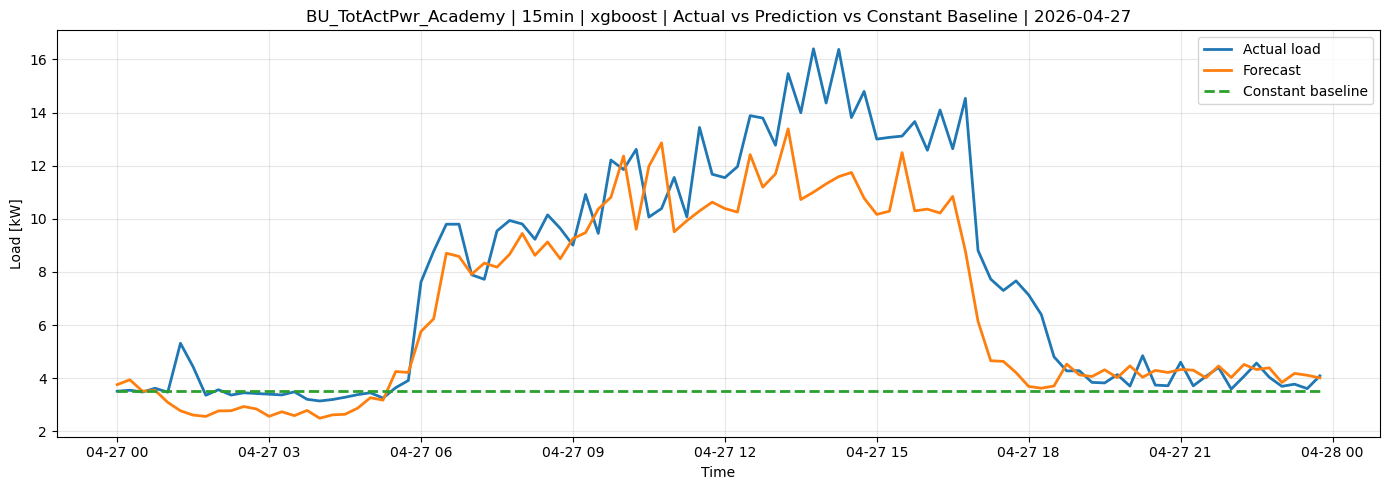

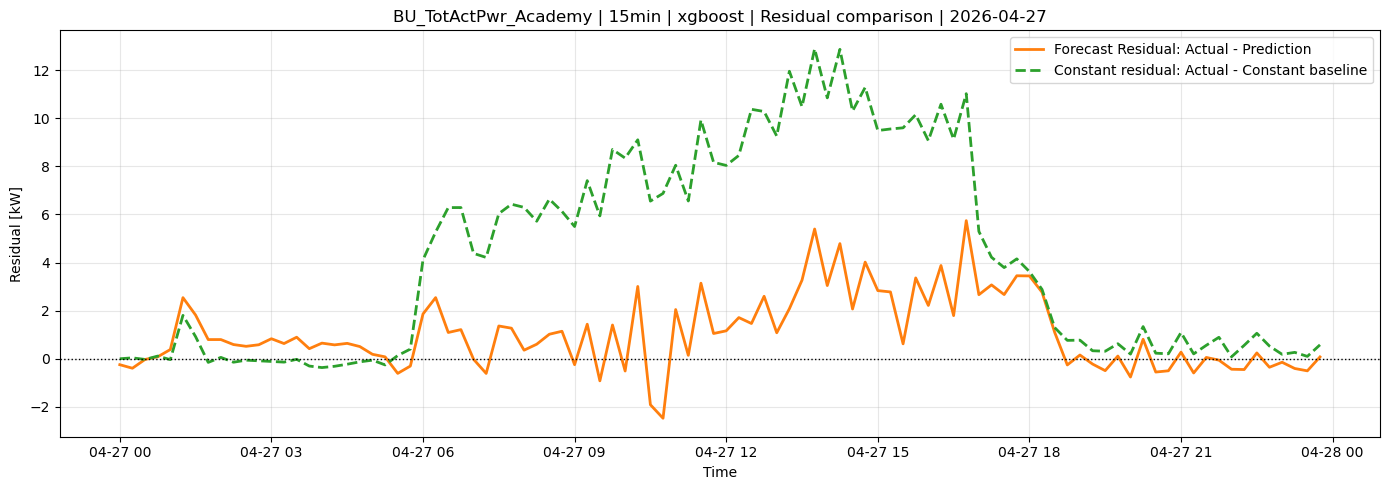

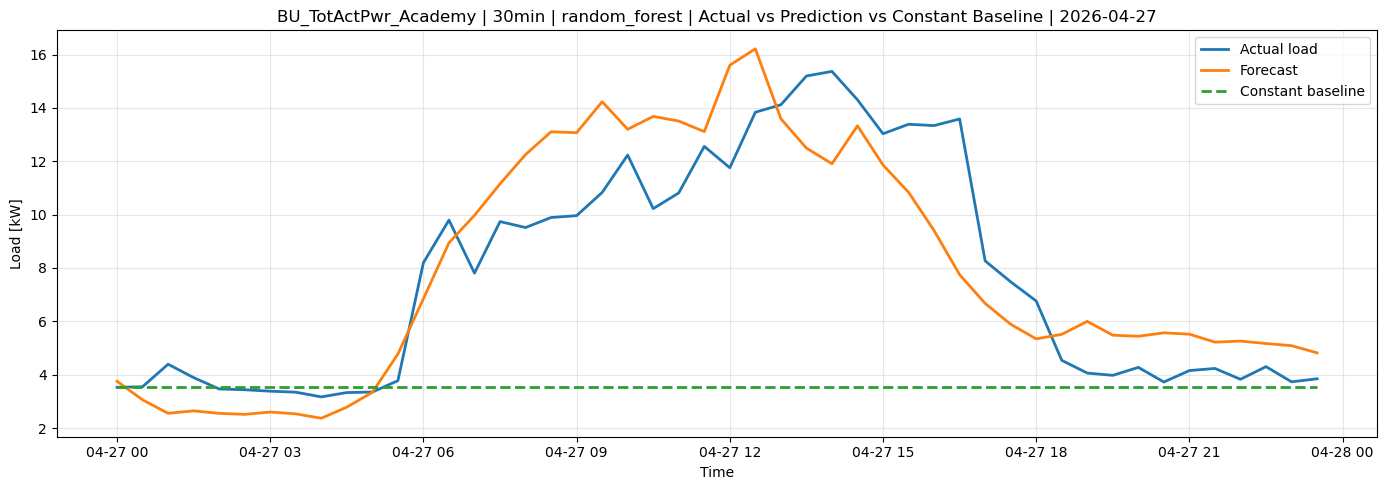

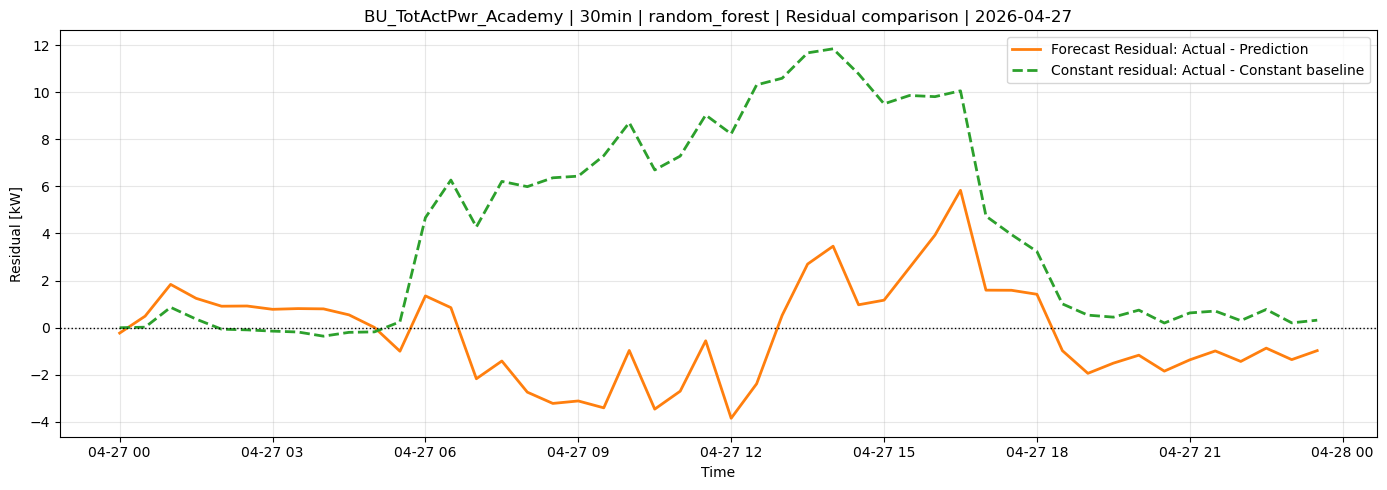

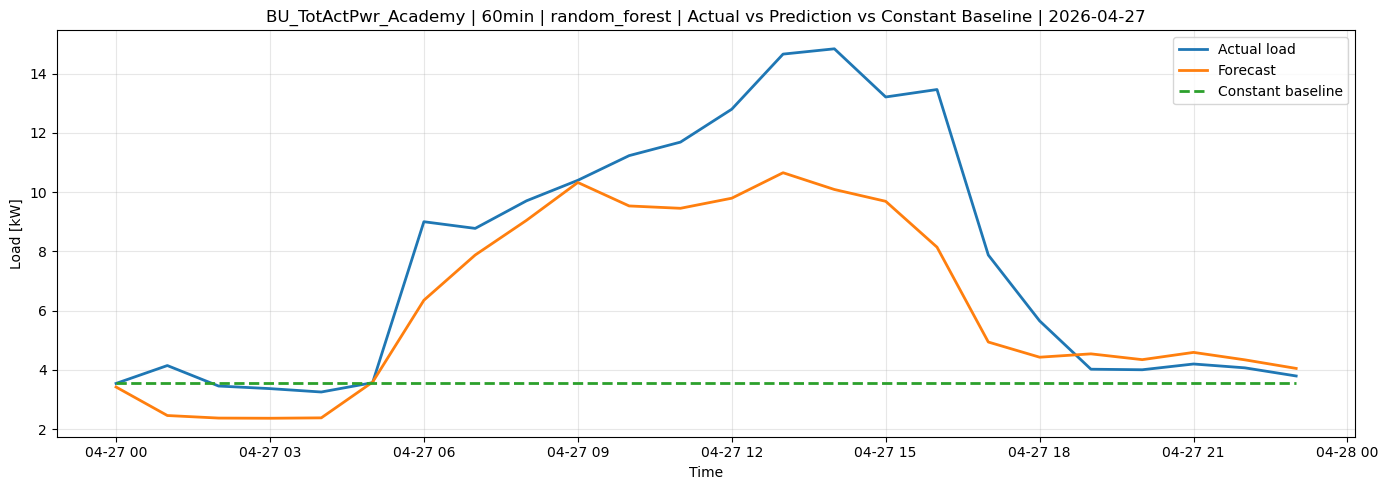

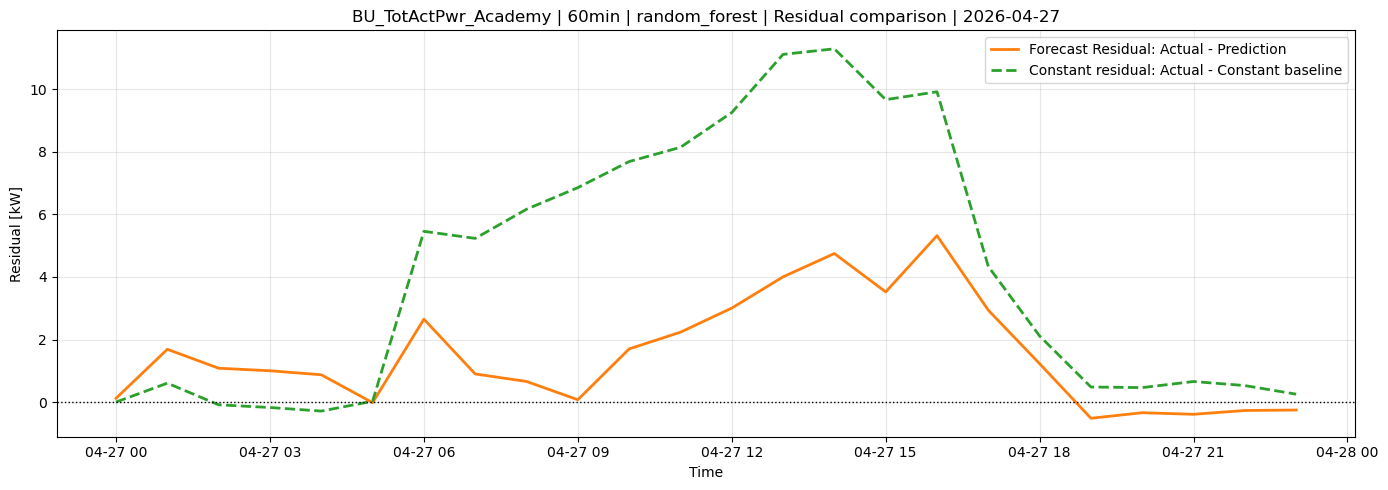

In [72]:
for _, best_row in best_each_resolution.iterrows():
    plot_forecast_and_residuals(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date="2026-04-27"
    )

### Select best ML model for each resolution during common dates

In [73]:
best_model_each_resolution_common = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),

        mean_actual_energy_kWh=("actual_energy_kWh", "mean"),
        mean_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "mean"),
        mean_constant_energy_kWh=("constant_energy_kWh", "mean"),

        mean_ml_signed_energy_error_kWh=("ml_signed_energy_error_kWh", "mean"),
        mean_constant_signed_energy_error_kWh=("constant_signed_energy_error_kWh", "mean"),

        mean_ml_absolute_energy_error_kWh=("ml_absolute_energy_error_kWh", "mean"),
        mean_ml_absolute_energy_error_percent=("ml_absolute_energy_error_%", "mean"),

        mean_constant_absolute_energy_error_kWh=("constant_absolute_energy_error_kWh", "mean"),
        mean_constant_absolute_energy_error_percent=("constant_absolute_energy_error_%", "mean"),

        mean_ml_improvement_vs_constant_kWh=("ml_improvement_vs_constant_kWh", "mean"),
        mean_ml_improvement_vs_constant_percent=("ml_improvement_vs_constant_%", "mean"),

        mean_ml_residual_kW=("ml_mean_residual_kW", "mean"),
        mean_constant_residual_kW=("constant_mean_residual_kW", "mean"),
    )
    .sort_values(["resolution", "mean_ml_absolute_energy_error_kWh"])
    .groupby("resolution", as_index=False)
    .first()
)

display(best_model_each_resolution_common)

,resolution,model_name,file_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW
0,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,8,158.565797,158.376672,88.99698,0.189125,69.568817,29.558080,20.477633,74.282828,43.938212,44.724747,29.744413,0.007880,2.898701
1,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,8,158.527170,178.946263,90.35703,-20.419093,68.170140,38.487983,27.410292,72.994736,43.148351,34.506753,-3.342269,-0.850796,2.840422
2,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,8,158.515481,164.015870,88.65150,-5.500389,69.863981,34.576039,25.591586,73.225176,43.307650,38.649138,-2.266626,-0.229183,2.910999


In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def sort_horizon_columns(cols):
    def horizon_number(col):
        base = col.replace("_true", "").replace("_pred", "")
        nums = [p for p in base.split("_") if p.isdigit()]
        return int(nums[-1]) if nums else 999999

    return sorted(cols, key=horizon_number)


def get_dt_hours_from_resolution(resolution):
    if resolution == "15min":
        return 0.25
    if resolution == "30min":
        return 0.5
    if resolution == "60min":
        return 1.0
    raise ValueError(f"Unknown resolution: {resolution}")


def plot_common_day_best_resolution(best_row, pred_dir, forecast_date):
    file_path = pred_dir / best_row["file_name"]

    resolution = best_row["resolution"]
    model_name = best_row["model_name"]
    dt_hours = get_dt_hours_from_resolution(resolution)

    load_name = best_row.get("target_col", target_col)

    df = pd.read_csv(file_path)

    df = df.rename(columns={df.columns[0]: "issue_time"})
    df["issue_time"] = pd.to_datetime(df["issue_time"], errors="coerce")
    df = df.dropna(subset=["issue_time"]).copy()

    true_cols = sort_horizon_columns([c for c in df.columns if c.endswith("_true")])
    pred_cols = [c.replace("_true", "_pred") for c in true_cols]

    df["forecast_date"] = (df["issue_time"] + pd.Timedelta(days=1)).dt.date

    forecast_date = pd.to_datetime(forecast_date).date()

    row_df = df[df["forecast_date"] == forecast_date].copy()

    if row_df.empty:
        print(f"No forecast found for {forecast_date} | {resolution} | {model_name}")
        return

    r = row_df.iloc[0]

    y_true = pd.to_numeric(r[true_cols], errors="coerce").to_numpy(dtype=float)
    y_pred = pd.to_numeric(r[pred_cols], errors="coerce").to_numpy(dtype=float)

    constant_load = y_true[0]
    y_constant = np.full_like(y_true, constant_load)

    valid = ~(np.isnan(y_true) | np.isnan(y_pred) | np.isnan(y_constant))

    y_true = y_true[valid]
    y_pred = y_pred[valid]
    y_constant = y_constant[valid]

    ml_residual = y_true - y_pred
    constant_residual = y_true - y_constant

    issue_time = r["issue_time"]
    step_minutes = int(dt_hours * 60)

    horizon_times = pd.date_range(
        start=issue_time + pd.Timedelta(minutes=step_minutes),
        periods=len(y_true),
        freq=f"{step_minutes}min"
    )

    actual_color = "tab:blue"
    ml_color = "tab:orange"
    constant_color = "tab:green"

    # ==============================
    # Plot 1: Actual vs ML vs Constant
    # ==============================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        y_true,
        label="Actual load",
        color=actual_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_pred,
        label="ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        y_constant,
        label="Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.title(
        f"{load_name} | {resolution} | {model_name} | "
        f"Actual vs ML Prediction vs Constant Baseline | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Load [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

    # ==============================
    # Plot 2: Residuals
    # ==============================

    plt.figure(figsize=(14, 5))

    plt.plot(
        horizon_times,
        ml_residual,
        label="ML residual: Actual - ML prediction",
        color=ml_color,
        linewidth=2
    )

    plt.plot(
        horizon_times,
        constant_residual,
        label="Constant residual: Actual - Constant baseline",
        color=constant_color,
        linewidth=2,
        linestyle="--"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":",
        linewidth=1
    )

    plt.title(
        f"{load_name} | {resolution} | {model_name} | "
        f"Residual comparison | {forecast_date}"
    )

    plt.xlabel("Time")
    plt.ylabel("Residual [kW]")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

Plotting common forecast date: 2026-04-20


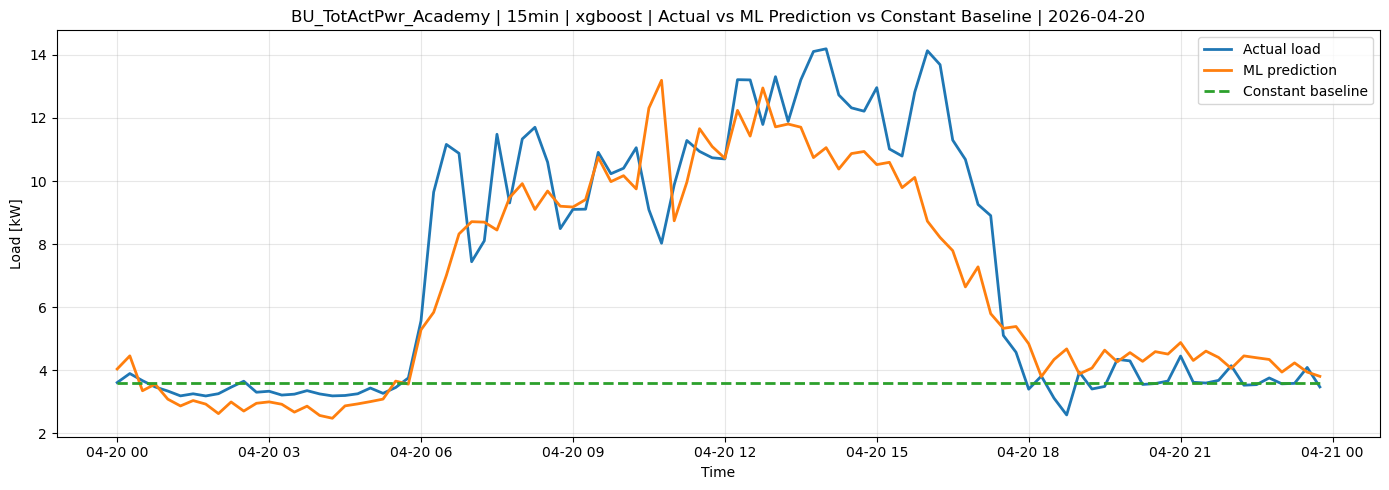

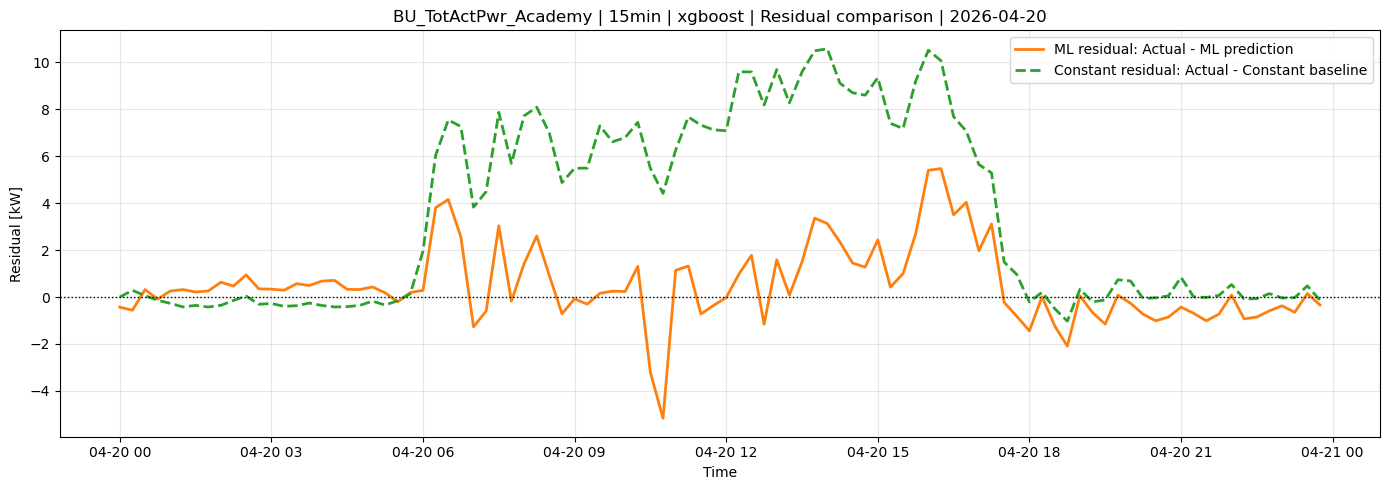

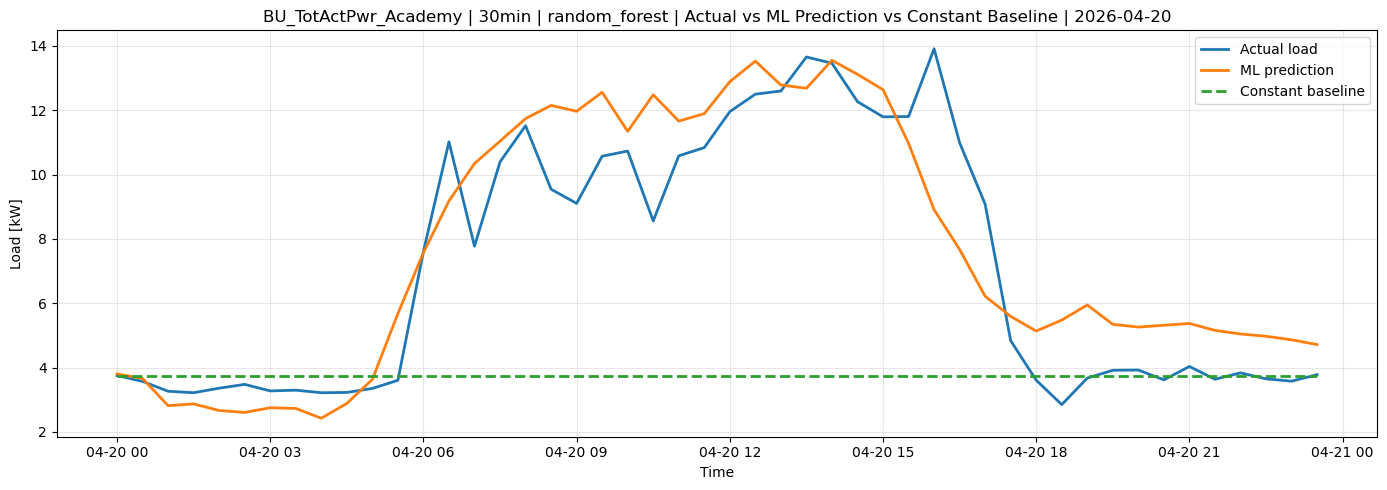

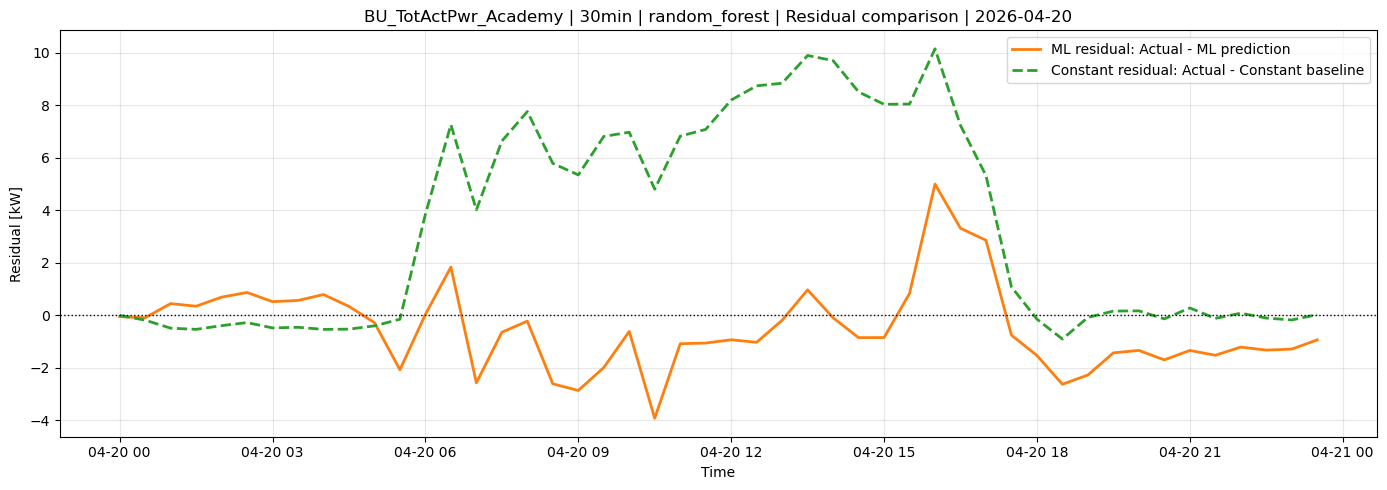

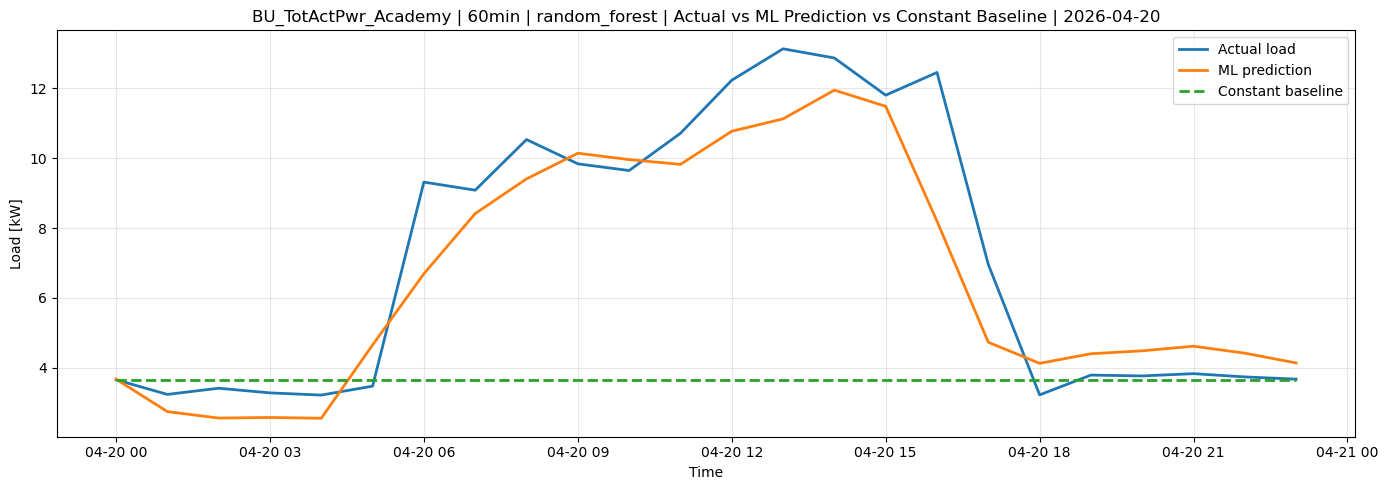

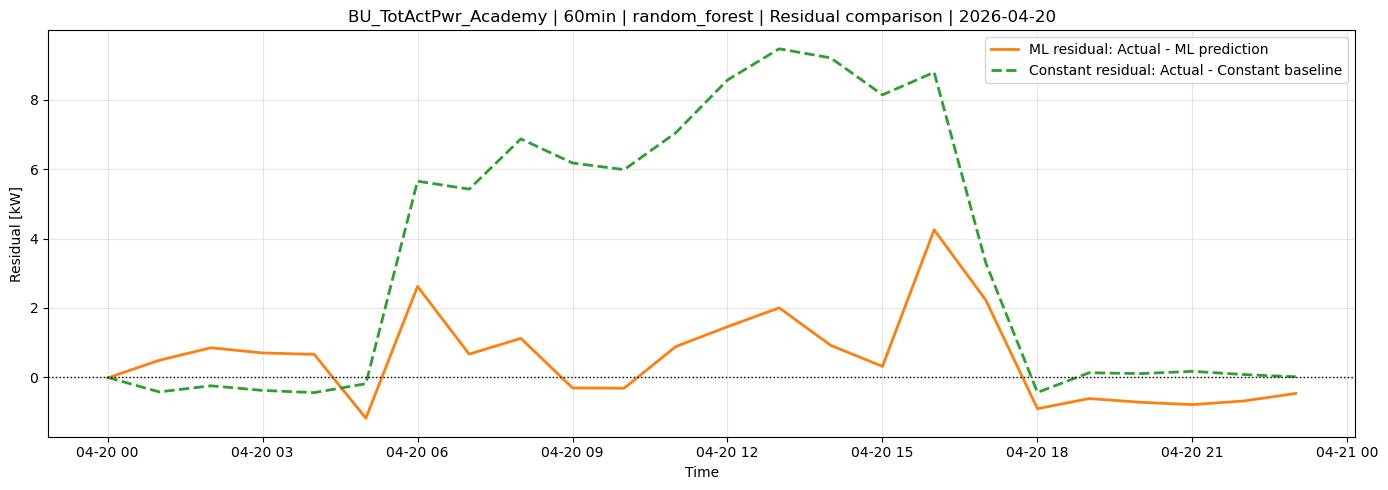

In [61]:
plot_date = common_dates[0]

print("Plotting common forecast date:", plot_date)

for _, best_row in best_model_each_resolution_common.iterrows():
    plot_common_day_best_resolution(
        best_row=best_row,
        pred_dir=pred_dir,
        forecast_date=plot_date
    )

In [62]:
final_common_resolution_comparison = best_model_each_resolution_common[
    [
        "resolution",
        "model_name",
        "n_common_days",

        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",

        "mean_ml_signed_energy_error_kWh",
        "mean_constant_signed_energy_error_kWh",

        "mean_ml_absolute_energy_error_kWh",
        "mean_ml_absolute_energy_error_percent",

        "mean_constant_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_percent",

        "mean_ml_improvement_vs_constant_kWh",
        "mean_ml_improvement_vs_constant_percent",

        "mean_ml_residual_kW",
        "mean_constant_residual_kW",

        "file_name",
    ]
].sort_values("mean_ml_absolute_energy_error_kWh")

display(final_common_resolution_comparison)

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_signed_energy_error_kWh,mean_constant_signed_energy_error_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_kWh,mean_ml_improvement_vs_constant_percent,mean_ml_residual_kW,mean_constant_residual_kW,file_name
0,15min,xgboost,8,158.565797,158.376672,88.99698,0.189125,69.568817,29.558080,20.477633,74.282828,43.938212,44.724747,29.744413,0.007880,2.898701,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...
2,60min,random_forest,8,158.515481,164.015870,88.65150,-5.500389,69.863981,34.576039,25.591586,73.225176,43.307650,38.649138,-2.266626,-0.229183,2.910999,run_20260521_093016_89fcbb0f_random_forest_BU_...
1,30min,random_forest,8,158.527170,178.946263,90.35703,-20.419093,68.170140,38.487983,27.410292,72.994736,43.148351,34.506753,-3.342269,-0.850796,2.840422,run_20260526_154855_5f504912_random_forest_BU_...


In [63]:
import matplotlib.pyplot as plt
import numpy as np


# Final summary table for plotting
energy_bar_summary = best_model_each_resolution_common.copy()

energy_bar_summary = energy_bar_summary.sort_values("resolution")

display(energy_bar_summary[
    [
        "resolution",
        "model_name",
        "n_common_days",
        "mean_ml_absolute_energy_error_kWh",
        "mean_constant_absolute_energy_error_kWh",
        "mean_ml_improvement_vs_constant_percent",
    ]
])


,resolution,model_name,n_common_days,mean_ml_absolute_energy_error_kWh,mean_constant_absolute_energy_error_kWh,mean_ml_improvement_vs_constant_percent
0,15min,xgboost,8,29.558080,74.282828,29.744413
1,30min,random_forest,8,38.487983,72.994736,-3.342269
2,60min,random_forest,8,34.576039,73.225176,-2.266626


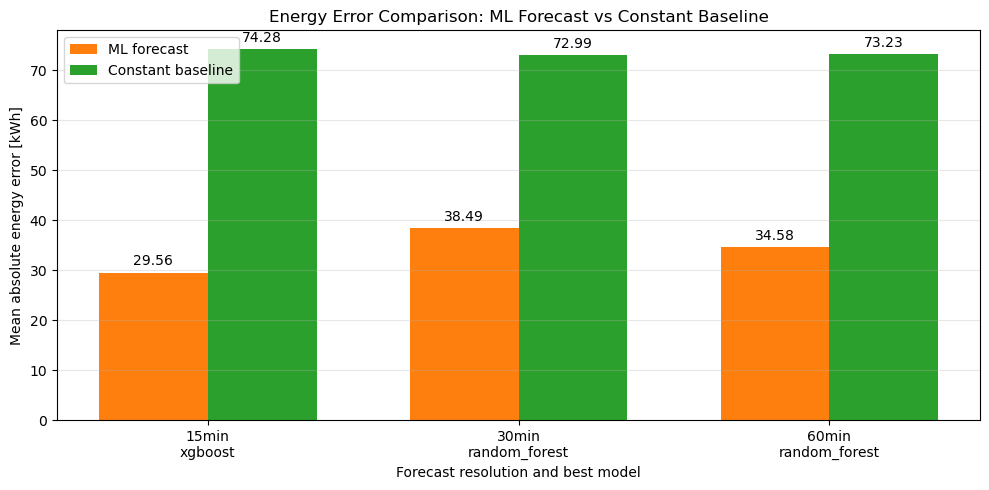

In [64]:
def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3)


x = np.arange(len(energy_bar_summary))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    energy_bar_summary["mean_ml_absolute_energy_error_kWh"],
    width,
    label="ML forecast",
    color="tab:orange"
)

ax.bar(
    x + width / 2,
    energy_bar_summary["mean_constant_absolute_energy_error_kWh"],
    width,
    label="Constant baseline",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    energy_bar_summary["resolution"] + "\n" + energy_bar_summary["model_name"]
)

ax.set_ylabel("Mean absolute energy error [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Energy Error Comparison: ML Forecast vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

,resolution,model_name,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh
0,15min,xgboost,8,158.565797,158.376672,88.99698
1,30min,random_forest,8,158.527170,178.946263,90.35703
2,60min,random_forest,8,158.515481,164.015870,88.65150


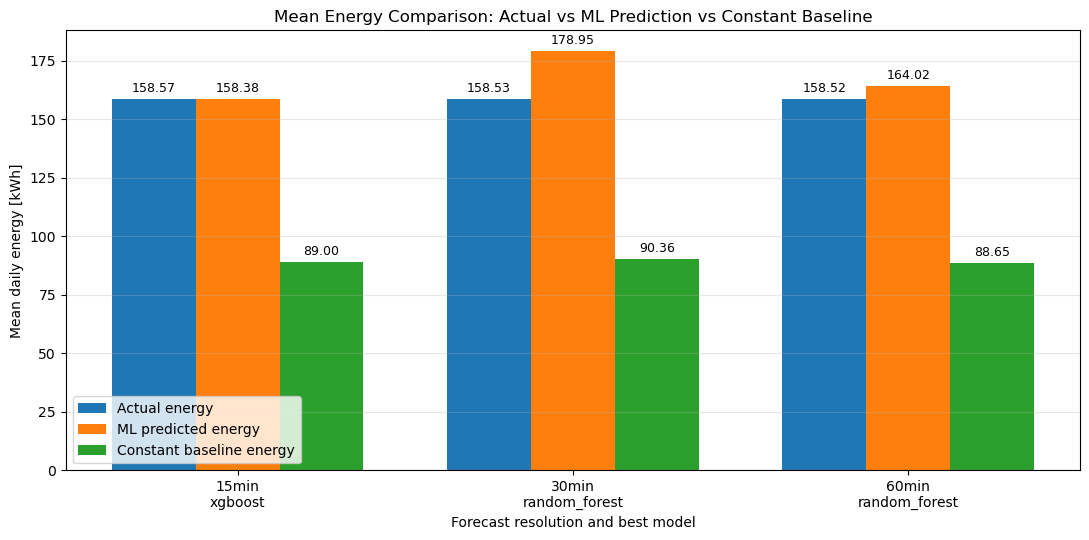

In [65]:
import numpy as np
import matplotlib.pyplot as plt


# Use the best model for each resolution on common forecast dates
energy_total_summary = best_model_each_resolution_common.copy()

# Optional: order resolutions correctly
resolution_order = {"15min": 0, "30min": 1, "60min": 2}
energy_total_summary["resolution_order"] = energy_total_summary["resolution"].map(resolution_order)
energy_total_summary = energy_total_summary.sort_values("resolution_order").reset_index(drop=True)

display(energy_total_summary[
    [
        "resolution",
        "model_name",
        "n_common_days",
        "mean_actual_energy_kWh",
        "mean_ml_predicted_energy_kWh",
        "mean_constant_energy_kWh",
    ]
])


def add_bar_labels(ax, fmt="{:.2f}"):
    for container in ax.containers:
        ax.bar_label(container, fmt=fmt, padding=3, fontsize=9)


x = np.arange(len(energy_total_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    energy_total_summary["mean_actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    energy_total_summary["mean_ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    energy_total_summary["mean_constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    energy_total_summary["resolution"] + "\n" + energy_total_summary["model_name"]
)

ax.set_ylabel("Mean daily energy [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Mean Energy Comparison: Actual vs ML Prediction vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

### total energy over all common days

,resolution,model_name,file_name,n_common_days,total_actual_energy_kWh,total_ml_predicted_energy_kWh,total_constant_energy_kWh,resolution_order
0,15min,xgboost,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,8,1268.526377,1267.013380,711.97584,0
1,30min,random_forest,run_20260526_154855_5f504912_random_forest_BU_...,8,1268.217360,1431.570103,722.85624,1
2,60min,random_forest,run_20260521_093016_89fcbb0f_random_forest_BU_...,8,1268.123850,1312.126960,709.21200,2


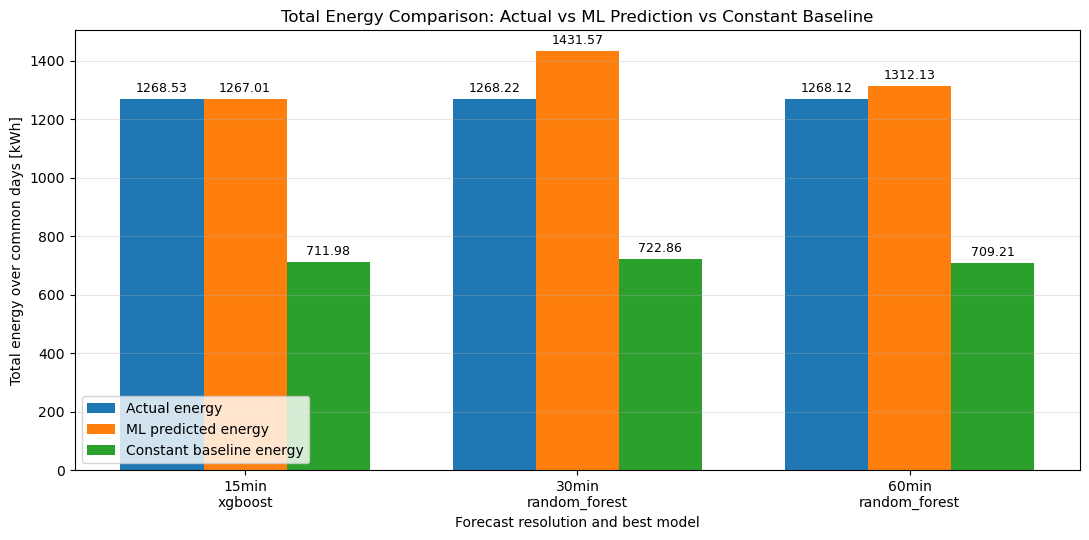

In [66]:
total_energy_summary = (
    energy_common_dates
    .groupby(["resolution", "model_name", "file_name"], as_index=False)
    .agg(
        n_common_days=("forecast_date", "nunique"),
        total_actual_energy_kWh=("actual_energy_kWh", "sum"),
        total_ml_predicted_energy_kWh=("ml_predicted_energy_kWh", "sum"),
        total_constant_energy_kWh=("constant_energy_kWh", "sum"),
    )
)

# Keep only the best files selected earlier
total_energy_summary = total_energy_summary.merge(
    best_model_each_resolution_common[["resolution", "model_name", "file_name"]],
    on=["resolution", "model_name", "file_name"],
    how="inner"
)

resolution_order = {"15min": 0, "30min": 1, "60min": 2}
total_energy_summary["resolution_order"] = total_energy_summary["resolution"].map(resolution_order)
total_energy_summary = total_energy_summary.sort_values("resolution_order").reset_index(drop=True)

display(total_energy_summary)


x = np.arange(len(total_energy_summary))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.bar(
    x - width,
    total_energy_summary["total_actual_energy_kWh"],
    width,
    label="Actual energy",
    color="tab:blue"
)

ax.bar(
    x,
    total_energy_summary["total_ml_predicted_energy_kWh"],
    width,
    label="ML predicted energy",
    color="tab:orange"
)

ax.bar(
    x + width,
    total_energy_summary["total_constant_energy_kWh"],
    width,
    label="Constant baseline energy",
    color="tab:green"
)

ax.set_xticks(x)
ax.set_xticklabels(
    total_energy_summary["resolution"] + "\n" + total_energy_summary["model_name"]
)

ax.set_ylabel("Total energy over common days [kWh]")
ax.set_xlabel("Forecast resolution and best model")
ax.set_title("Total Energy Comparison: Actual vs ML Prediction vs Constant Baseline")
ax.grid(axis="y", alpha=0.3)
ax.legend()

add_bar_labels(ax, fmt="{:.2f}")

plt.tight_layout()
plt.show()

In [67]:
from pathlib import Path
import pandas as pd


# ============================================================
# SETTINGS
# ============================================================

pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
target_col = "BU_TotActPwr_Tech_Room"


# ============================================================
# FUNCTION TO EXTRACT RUN ID FROM FILE NAME
# ============================================================

def extract_run_id(file_name):
    """
    Example:
    run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv

    run_id:
    run_20260521_105037_ca9fc1b2
    """
    parts = file_name.split("_")
    return "_".join(parts[:4])


# ============================================================
# CLEAN ERROR SUMMARY
# ============================================================

error_summary_clean = error_summary.copy()

# Remove invalid/unknown rows
error_summary_clean = error_summary_clean[
    error_summary_clean["resolution"].isin(["15min", "30min", "60min"])
].copy()

error_summary_clean = error_summary_clean[
    error_summary_clean["model_name"] != "unknown"
].copy()

# Add run id and full prediction path
error_summary_clean["run_id"] = error_summary_clean["file_name"].apply(extract_run_id)
error_summary_clean["prediction_path"] = error_summary_clean["file_name"].apply(
    lambda x: str(pred_dir / x)
)


# ============================================================
# BEST MODEL PER RESOLUTION BASED ON LOWEST MAE
# ============================================================

best_model_each_resolution = (
    error_summary_clean
    .sort_values(["resolution", "MAE"])
    .groupby("resolution", as_index=False)
    .first()
)

# Optional: order resolution properly
resolution_order = {"15min": 0, "30min": 1, "60min": 2}
best_model_each_resolution["resolution_order"] = (
    best_model_each_resolution["resolution"].map(resolution_order)
)

best_model_each_resolution = (
    best_model_each_resolution
    .sort_values("resolution_order")
    .drop(columns=["resolution_order"])
    .reset_index(drop=True)
)


# ============================================================
# FINAL TABLE TO DISPLAY
# ============================================================

best_model_paths_table = best_model_each_resolution[
    [
        "resolution",
        "model_name",
        "run_id",
        "target_col",
        "first_forecast_date",
        "last_forecast_date",
        "n_forecast_days",
        "n_issue_times",
        "n_horizon_steps",
        "MAE",
        "RMSE",
        "MAPE_%",
        "R2",
        "bias_actual_minus_pred",
        "error_std",
        "file_name",
        "prediction_path",
    ]
].copy()

display(best_model_paths_table)

,resolution,model_name,run_id,target_col,first_forecast_date,last_forecast_date,n_forecast_days,n_issue_times,n_horizon_steps,MAE,RMSE,MAPE_%,R2,bias_actual_minus_pred,error_std,file_name,prediction_path
0,15min,xgboost,run_20260512_171555_4d7cc794,BU_TotActPwr_Academy,2026-04-20,2026-04-29,8,8,96,1.231587,1.763725,19.936692,0.779974,0.007880,1.763707,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,30min,random_forest,run_20260526_154855_5f504912,BU_TotActPwr_Academy,2026-04-20,2026-04-30,11,11,48,1.572814,2.033778,28.281425,0.695043,-0.896188,1.825678,run_20260526_154855_5f504912_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,60min,random_forest,run_20260521_093016_89fcbb0f,BU_TotActPwr_Academy,2026-04-20,2026-04-30,11,11,24,1.309780,1.949535,22.845292,0.708234,-0.267631,1.931078,run_20260521_093016_89fcbb0f_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [68]:
best_energy_model_paths_table = best_model_each_resolution_common.copy()

best_energy_model_paths_table["run_id"] = best_energy_model_paths_table["file_name"].apply(extract_run_id)
best_energy_model_paths_table["prediction_path"] = best_energy_model_paths_table["file_name"].apply(
    lambda x: str(pred_dir / x)
)

best_energy_model_paths_table = best_energy_model_paths_table[
    [
        "resolution",
        "model_name",
        "run_id",
        "n_common_days",
        "prediction_path",
    ]
]

display(best_energy_model_paths_table)

,resolution,model_name,run_id,n_common_days,prediction_path
0,15min,xgboost,run_20260512_171555_4d7cc794,8,C:\Data_analysis\Thesis\outputs\profile_foreca...
1,30min,random_forest,run_20260526_154855_5f504912,8,C:\Data_analysis\Thesis\outputs\profile_foreca...
2,60min,random_forest,run_20260521_093016_89fcbb0f,8,C:\Data_analysis\Thesis\outputs\profile_foreca...


In [69]:
from pathlib import Path

pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")

best_prediction_paths = [
    str(pred_dir / file_name)
    for file_name in best_model_each_resolution_common["file_name"]
]

for path in best_prediction_paths:
    print(path)

C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260512_171555_4d7cc794_xgboost_BU_TotActPwr_Academy_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260526_154855_5f504912_random_forest_BU_TotActPwr_Academy_profile_predictions.csv
C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions\run_20260521_093016_89fcbb0f_random_forest_BU_TotActPwr_Academy_profile_predictions.csv


In [70]:
from pathlib import Path
import pandas as pd
from datetime import datetime


pred_dir = Path(r"C:\Data_analysis\Thesis\outputs\profile_forecasting\predictions")
registry_path = pred_dir.parent / "best_prediction_files_registry.csv"


def extract_run_id(file_name):
    parts = file_name.split("_")
    return "_".join(parts[:4])


def extract_target_col_from_file_name(file_name, model_name):
    """
    Example:
    run_20260521_105037_ca9fc1b2_random_forest_BU_TotActPwr_Tech_Room_profile_predictions.csv

    Returns:
    BU_TotActPwr_Tech_Room
    """

    name = file_name.replace("_profile_predictions.csv", "")

    run_id = extract_run_id(file_name)

    # Remove run_id part
    remaining = name.replace(run_id + "_", "")

    # Remove model name part
    remaining = remaining.replace(model_name + "_", "", 1)

    return remaining


current_best_paths = best_model_each_resolution_common.copy()

current_best_paths["run_id"] = current_best_paths["file_name"].apply(extract_run_id)

current_best_paths["target_col"] = current_best_paths.apply(
    lambda row: extract_target_col_from_file_name(
        row["file_name"],
        row["model_name"]
    ),
    axis=1
)

current_best_paths["prediction_path"] = current_best_paths["file_name"].apply(
    lambda x: str(pred_dir / x)
)

current_best_paths["registry_added_at"] = datetime.now().strftime("%Y-%m-%d %H:%M:%S")


wanted_cols = [
    "registry_added_at",
    "target_col",
    "resolution",
    "model_name",
    "run_id",
    "file_name",
    "prediction_path",
    "n_common_days",
    "mean_actual_energy_kWh",
    "mean_ml_predicted_energy_kWh",
    "mean_constant_energy_kWh",
    "mean_ml_absolute_energy_error_kWh",
    "mean_ml_absolute_energy_error_percent",
    "mean_constant_absolute_energy_error_kWh",
    "mean_constant_absolute_energy_error_percent",
    "mean_ml_improvement_vs_constant_percent",
]

current_best_paths = current_best_paths[
    [c for c in wanted_cols if c in current_best_paths.columns]
].copy()


if registry_path.exists():
    registry = pd.read_csv(registry_path)
    registry = pd.concat([registry, current_best_paths], ignore_index=True)
else:
    registry = current_best_paths.copy()


duplicate_key_cols = [
    "target_col",
    "resolution",
    "model_name",
    "run_id",
    "file_name",
    "prediction_path",
]

registry = registry.drop_duplicates(
    subset=[c for c in duplicate_key_cols if c in registry.columns],
    keep="first"
).copy()


resolution_order = {"15min": 0, "30min": 1, "60min": 2}
registry["resolution_order"] = registry["resolution"].map(resolution_order)

registry = (
    registry
    .sort_values(["target_col", "resolution_order", "registry_added_at"])
    .drop(columns=["resolution_order"])
    .reset_index(drop=True)
)

registry.to_csv(registry_path, index=False)

print("Registry saved/updated:")
print(registry_path)

display(registry)

Registry saved/updated:
C:\Data_analysis\Thesis\outputs\profile_forecasting\best_prediction_files_registry.csv


,registry_added_at,target_col,resolution,model_name,run_id,file_name,prediction_path,n_common_days,mean_actual_energy_kWh,mean_ml_predicted_energy_kWh,mean_constant_energy_kWh,mean_ml_absolute_energy_error_kWh,mean_ml_absolute_energy_error_percent,mean_constant_absolute_energy_error_kWh,mean_constant_absolute_energy_error_percent,mean_ml_improvement_vs_constant_percent
0,2026-06-10 08:13:23,BA_TotActPwr_BESS_AC_Panel1,15min,catboost,run_20260520_140855_d633be27,run_20260520_140855_d633be27_catboost_BA_TotAc...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,39.456767,40.612130,18.927120,28.353321,74.746262,33.280606,86.907089,14.537979
1,2026-06-10 08:13:23,BA_TotActPwr_BESS_AC_Panel1,30min,random_forest,run_20260609_114248_491ef4c5,run_20260609_114248_491ef4c5_random_forest_BA_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,39.488196,42.652230,19.102693,29.168079,77.706209,32.867367,85.878706,10.141346
2,2026-06-10 08:13:23,BA_TotActPwr_BESS_AC_Panel1,60min,catboost,run_20260513_093323_6c5af549,run_20260513_093323_6c5af549_catboost_BA_TotAc...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,39.490012,41.580654,18.500907,28.056533,74.898856,31.464223,82.154165,9.890357
3,2026-06-10 09:07:31,BA_TotActPwr_BESS_AC_Panel2,15min,xgboost,run_20260513_163428_b21d7ab7,run_20260513_163428_b21d7ab7_xgboost_BA_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,7,41.452013,38.839421,28.621680,29.332888,72.733149,27.968411,70.605153,-6.962368
4,2026-06-10 09:07:31,BA_TotActPwr_BESS_AC_Panel2,30min,random_forest,run_20260526_171039_68f3c8d8,run_20260526_171039_68f3c8d8_random_forest_BA_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,7,41.452006,42.235171,32.485714,29.117473,73.245779,26.305689,66.314449,-11.975691
5,2026-06-10 09:07:31,BA_TotActPwr_BESS_AC_Panel2,60min,ridge,run_20260610_082523_e14609ea,run_20260610_082523_e14609ea_ridge_BA_TotActPw...,C:\Data_analysis\Thesis\outputs\profile_foreca...,7,41.452013,39.485055,32.459726,27.278024,68.561917,24.409239,61.229224,-11.321387
6,2026-05-29 13:43:08,BU_TotActPwr_Academy,15min,xgboost,run_20260512_171555_4d7cc794,run_20260512_171555_4d7cc794_xgboost_BU_TotAct...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.565797,158.376672,88.996980,29.558080,20.477633,74.282828,43.938212,29.744413
7,2026-05-29 13:43:08,BU_TotActPwr_Academy,30min,random_forest,run_20260526_154855_5f504912,run_20260526_154855_5f504912_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.527170,178.946263,90.357030,38.487983,27.410292,72.994736,43.148351,-3.342269
8,2026-05-29 13:43:08,BU_TotActPwr_Academy,60min,random_forest,run_20260521_093016_89fcbb0f,run_20260521_093016_89fcbb0f_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,8,158.515481,164.015870,88.651500,34.576039,25.591586,73.225176,43.307650,-2.266626
9,2026-05-29 13:43:29,BU_TotActPwr_SDB_EL_Substation,15min,random_forest,run_20260528_115442_63c0a563,run_20260528_115442_63c0a563_random_forest_BU_...,C:\Data_analysis\Thesis\outputs\profile_foreca...,9,81.565080,85.681771,109.140480,14.728917,18.065516,36.265066,44.529342,57.470873
